# Qiskit: Cổng lượng tử từ cơ bản đến nâng cao

Demo các thao tác với cổng lượng tử trong Qiskit: cổng đơn/đa qubit, cổng tham số, cổng điều khiển, Unitary tuỳ biến, đóng gói subcircuit, đo đạc và mô phỏng. 
Còn nhiều cổng phức tạp chưa hiểu hết được :) 


## 0) Chuẩn bị môi trường

- Yêu cầu: `qiskit` (>=1.x) và `qiskit-aer` để mô phỏng.
- Nếu chạy cục bộ và chưa cài, hãy bỏ comment dòng `pip install` trong cell dưới.


In [1]:
# !pip install qiskit qiskit-aer pylatexenc
import qiskit
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.circuit import Parameter
from qiskit.circuit.library import UnitaryGate, RXGate
from qiskit.quantum_info import Statevector, Operator
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import numpy as np
import math
import matplotlib.pyplot as plt

print("Qiskit version:", qiskit.__version__)

Qiskit version: 1.4.5


## 1) Khởi tạo mạch và trạng thái ban đầu

- Mỗi **qubit** khởi tạo ở trạng thái \(|0\rangle\).
- Ta dùng 3 qubit và 3 bit cổ điển để đo.


In [2]:
q = QuantumRegister(3, "q")
c = ClassicalRegister(3, "c")
qc = QuantumCircuit(q, c, name="gate_demo")
qc

## 2) Cổng đơn qubit cơ bản (X, Y, Z, H, S, T)

- **X** ~ NOT: đổi \\(|0\\rangle \leftrightarrow |1\\rangle\\)
- **Y, Z**: phép quay quanh trục Y/Z trên Bloch
- **H**: Hadamard, tạo chồng chập: \\(H|0\\rangle = (|0\\rangle + |1\\rangle)/\sqrt{2}\\)
- **S (Phase)**: thêm pha \\(\pi/2\\); **T**: \\(\pi/4\\)

Ta áp dụng tuần tự và quan sát sơ đồ mạch.


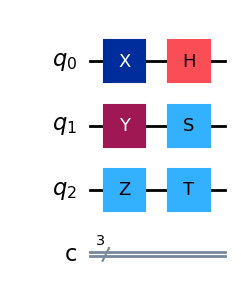

In [3]:
qc.x(q[0])   # Pauli-X trên qubit 0
qc.y(q[1])   # Pauli-Y trên qubit 1
qc.z(q[2])   # Pauli-Z trên qubit 2
qc.h(q[0])   # Hadamard trên qubit 0
qc.s(q[1])   # S gate trên qubit 1
qc.t(q[2])   # T gate trên qubit 2

qc.draw('mpl')

## 3) Cổng xoay tham số: \(R_x(\theta), R_y(\phi), R_z(\lambda)\) và \(U(\theta,\phi,\lambda)\)

- Các cổng quay cho phép ta tối ưu hoá góc quay trong thuật toán/variational.
- Dùng **Parameter** để định nghĩa tham số ký hiệu, sau đó **bind** giá trị khi chạy.


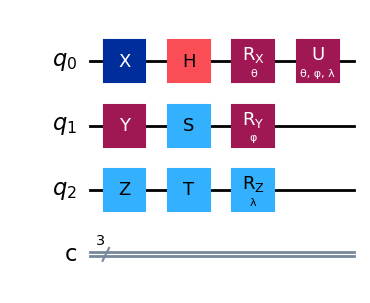

In [4]:
theta = Parameter("θ")
phi   = Parameter("φ")
lam   = Parameter("λ")

qc.rx(theta, q[0])
qc.ry(phi,   q[1])
qc.rz(lam,   q[2])
qc.u(theta, phi, lam, q[0])  # U tổng quát trên qubit 0

qc.draw('mpl')

## 4) Cổng hai/ba qubit phổ biến: CNOT, CZ, SWAP, Toffoli (CCX)

- **CNOT** tạo vướng víu (entanglement) khi target đang ở siêu vị tự nhiên (ví dụ sau H).
- **CZ**: tương tự CNOT nhưng theo pha.
- **SWAP**: hoán đổi trạng thái 2 qubit.
- **Toffoli (CCX)**: hai điều khiển, một đích (cổng triển khai tính toán cổ điển khả nghịch).


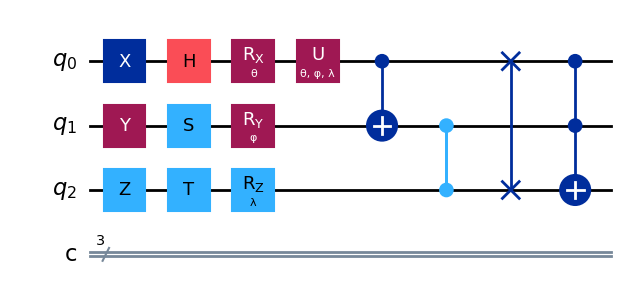

In [5]:
qc.cx(q[0], q[1])        # control q0 -> target q1
qc.cz(q[1], q[2])        # control q1 -> target q2 (pha)
qc.swap(q[0], q[2])      # hoán đổi q0 và q2
qc.ccx(q[0], q[1], q[2]) # Toffoli

qc.draw('mpl')

## 5) Biến bất kỳ gate thành **controlled-gate**

- Bất kỳ gate nào cũng có thể thêm qubit điều khiển bằng `.control(k)`.
- Ví dụ: tạo **CRX(θ)** từ `RXGate(θ)` với một qubit điều khiển.


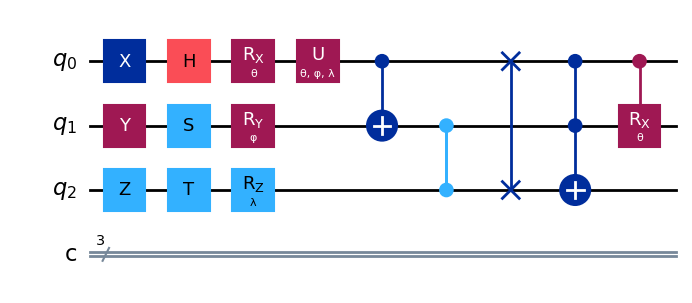

In [6]:
crx_gate = RXGate(theta).control(1)  # 1 qubit điều khiển
qc.append(crx_gate, [q[0], q[1]])     # q0 điều khiển, q1 bị tác động
qc.draw('mpl')

## 6) Tự định nghĩa **Unitary** tùy ý

- Với 2 qubit, ma trận phải là \\(4\\times 4\\) và **unitary**: \\(U^\dagger U = I\\).
- Ở ví dụ sau, ta tráo đổi \(|01\rangle \leftrightarrow |10\rangle\) (na ná SWAP có ràng buộc).


U is unitary? True


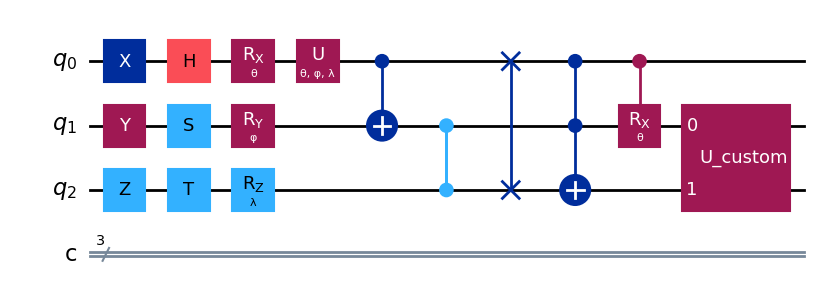

In [7]:
U = np.array([
    [1,0,0,0],
    [0,0,1,0],
    [0,1,0,0],
    [0,0,0,1]
], dtype=complex)

# Kiểm tra tính unitary (U^† U ≈ I)
is_unitary = np.allclose(U.conj().T @ U, np.eye(4), atol=1e-8)
print("U is unitary?", is_unitary)

custom_U = UnitaryGate(U, label="U_custom")
qc.append(custom_U, [q[1], q[2]])
qc.draw('mpl')

## 7) Đóng gói **subcircuit** thành gate dùng lại

- Tạo một mạch con (ví dụ *entangler*: H + CNOT), chuyển thành gate bằng `.to_gate()`.
- Có thể tạo **controlled-subgate** từ gate vừa đóng gói.


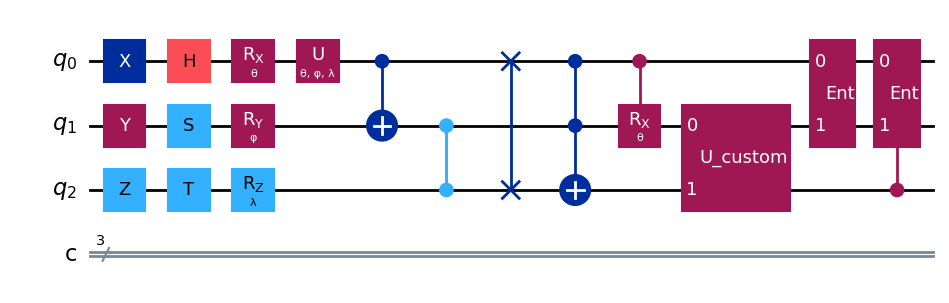

In [8]:
sub = QuantumCircuit(2, name="entangler")
sub.h(0)
sub.cx(0, 1)
entangler_gate = sub.to_gate()
entangler_gate.label = "Ent"
c_entangler_gate = entangler_gate.control(1)

qc.append(entangler_gate, [q[0], q[1]])
qc.append(c_entangler_gate, [q[2], q[0], q[1]])

qc.draw('mpl')

## 8) Đo lường & mô phỏng: **Statevector** vs **Counts**

- **Statevector**: biên độ phức của trạng thái, chỉ xem được khi **chưa đo**.
- **Counts**: tần suất kết quả bitstring sau khi đo (mô phỏng nhiều **shots**).
- Quy trình:
  1. Gán giá trị tham số (bind).
  2. Sao chép mạch bỏ đo để lấy statevector.
  3. Dùng **AerSimulator** chạy đo nhiều shots, vẽ histogram.


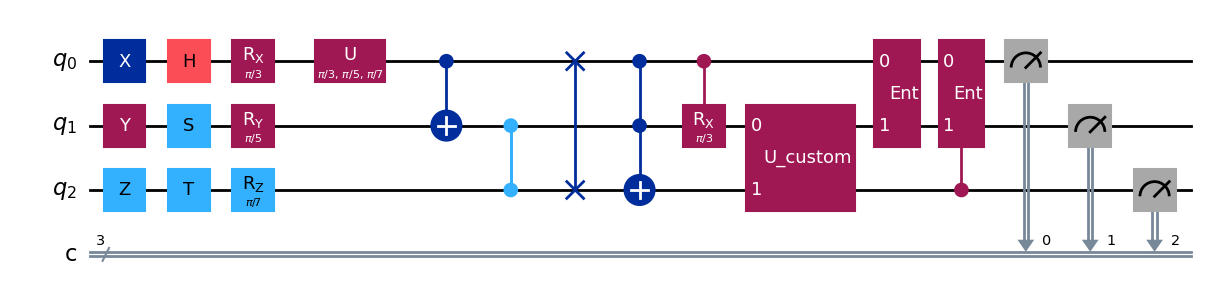

In [9]:
# 1) Gán tham số
param_binds = {theta: np.pi/3, phi: np.pi/5, lam: np.pi/7}
qc_bound = qc.assign_parameters(param_binds)

# Thêm đo
qc_meas = qc_bound.copy()
qc_meas.measure(q, c)

qc_meas.draw('mpl')

In [10]:
# 2) Statevector (từ mạch không đo)
qc_no_meas = qc_bound.remove_final_measurements(inplace=False)
sv = Statevector.from_instruction(qc_no_meas.decompose(reps=5))
print("Kích thước statevector:", len(sv))
print("8 biên độ đầu:", sv.data[:8])

Kích thước statevector: 8
8 biên độ đầu: [ 0.18449493+0.09198692j -0.06302956+0.21381303j -0.06302956+0.21381303j
  0.18449493+0.09198692j -0.38702603-0.24931078j  0.41598848+0.15106244j
 -0.38702603-0.24931078j -0.41598848-0.15106244j]


Counts (một phần): {'100': 871, '111': 800, '000': 166, '110': 889, '101': 787, '011': 171, '001': 193, '010': 219}


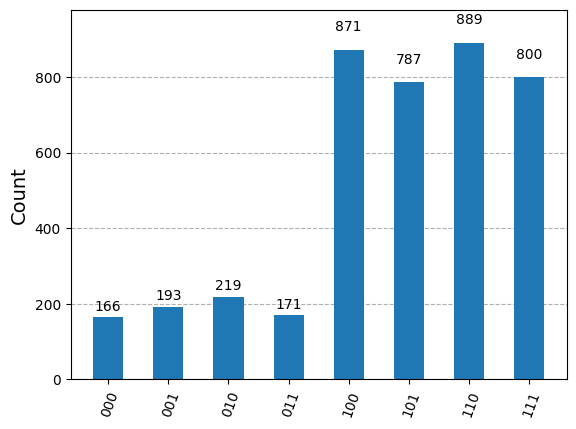

In [11]:
# 3) Mô phỏng đo đạc (counts) + histogram
sim = AerSimulator()
qc_meas_t = transpile(qc_meas, sim)
job = sim.run(qc_meas_t, shots=4096)
result = job.result()
counts = result.get_counts()

print("Counts (một phần):", dict(list(counts.items())[:8]))
fig = plot_histogram(counts)
fig

## 9) Mini-thí nghiệm: quét tham số để thấy xác suất đo

- Mạch một qubit: áp dụng \(R_y(\theta)\) lên \(|0\rangle\), sau đó đo.
- Lý thuyết: xác suất đo \(|1\rangle\) là \(\sin^2(\theta/2)\).
- Ta quét \(\theta \in [0, 2\pi]\) và so sánh thực nghiệm (mô phỏng) với công thức lý thuyết.


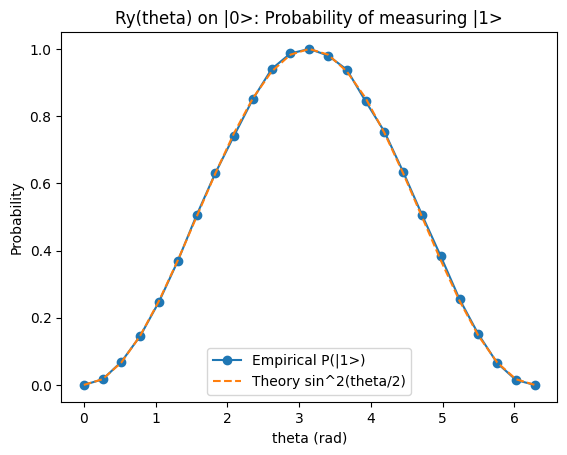

In [12]:
thetas = np.linspace(0, 2*np.pi, 25)
p1_empirical = []
p1_theory = []

sim = AerSimulator()
for th in thetas:
    qc1 = QuantumCircuit(1,1)
    qc1.ry(th, 0)
    qc1.measure(0,0)
    job = sim.run(qc1, shots=4096)
    counts = job.result().get_counts()
    p1 = counts.get('1', 0)/4096
    p1_empirical.append(p1)
    p1_theory.append(np.sin(th/2)**2)

plt.figure()
plt.plot(thetas, p1_empirical, marker='o', label='Empirical P(|1>)')
plt.plot(thetas, p1_theory, linestyle='--', label='Theory sin^2(theta/2)')
plt.xlabel('theta (rad)')
plt.ylabel('Probability')
plt.title('Ry(theta) on |0>: Probability of measuring |1>')
plt.legend()
plt.show()

## 10) Tạo trạng thái **GHZ** và đo

- GHZ 3-qubit: \((|000\rangle + |111\rangle)/\sqrt{2}\)
- Cách tạo: H trên qubit 0, rồi **CNOT** chuỗi 0→1 và 1→2.
- Khi đo nhiều shots, chủ yếu chỉ thấy hai kết quả `000` và `111`.


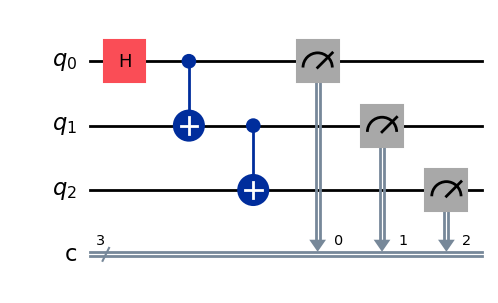

In [13]:
def make_ghz(n: int) -> QuantumCircuit:
    qc_ghz = QuantumCircuit(n, name=f"GHZ_{n}")
    qc_ghz.h(0)
    for i in range(n - 1):
        qc_ghz.cx(i, i + 1)
    return qc_ghz

ghz3 = make_ghz(3)
qc2 = QuantumCircuit(3,3,name="use_GHZ")
qc2.compose(ghz3, inplace=True)
qc2.measure([0,1,2],[0,1,2])

qc2.draw('mpl')

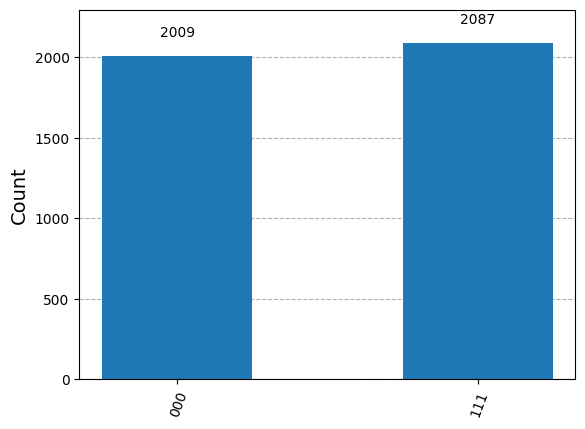

In [14]:
job2 = AerSimulator().run(qc2, shots=4096)
counts2 = job2.result().get_counts()
plot_histogram(counts2)

## 11) **Transpile**: ánh xạ mạch về các **basis gates** của phần cứng

- Trên phần cứng thực, chỉ một số **basis gates** khả dụng (ví dụ `sx, rz, x, cx`).
- `transpile` tối ưu và chuyển mạch về các basis tương thích backend.


In [15]:
backend = AerSimulator()  # giả lập phần cứng
qc_opt = transpile(qc_meas, backend=backend, basis_gates=['sx','rz','x','cx'], optimization_level=3)
print(qc_opt)

global phase: 3.2875
                                        ┌────────────┐┌────┐┌─────────────┐»
Qubit(QuantumRegister(3, 'q'), 0) -> 0 ─┤ Rz(1.4499) ├┤ √X ├┤ Rz(-2.4659) ├»
                                       ┌┴────────────┤├────┤├─────────────┤»
Qubit(QuantumRegister(3, 'q'), 1) -> 1 ┤ Rz(-0.6924) ├┤ √X ├┤ Rz(-2.2917) ├»
                                       ├─────────────┤├────┤└─┬─────────┬─┘»
Qubit(QuantumRegister(3, 'q'), 2) -> 2 ┤ Rz(-0.3366) ├┤ √X ├──┤ Rz(π/2) ├──»
                                       └─────────────┘└────┘  └─────────┘  »
                                  c: 3/════════════════════════════════════»
                                                                           »
«                                       ┌────┐┌──────────────┐        ┌────┐  »
«Qubit(QuantumRegister(3, 'q'), 0) -> 0 ┤ √X ├┤ Rz(-0.17585) ├──■─────┤ √X ├──»
«                                       ├────┤└┬────────────┬┘┌─┴─┐┌──┴────┴─┐»
«Qubit(QuantumRegister(3, 'q'), 1) -> 1 ┤ √X ├

## 12) Bổ sung

- Dùng `.control(k)` để thêm **k** qubit điều khiển cho gần như mọi gate.
- Dùng `.to_gate()` hoặc `.to_instruction()` để tái sử dụng **subcircuit**.
- Dùng `Statevector` cho phân tích thuật toán (trước đo); dùng `AerSimulator` + `shots` để thống kê đo.
- Khi tự xây Unitary, luôn kiểm tra `U.conj().T @ U ≈ I`.
- Dùng `transpile` để xem mạch sẽ chạy thế nào trên backend/basis cụ thể.
